# Testing BaselineGCN with undirected edge GNNdataset

In [1]:
from torch.utils.data import random_split
import numpy as np
import importlib
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)

In [2]:
from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelTrainer import GNNTrainer
from atoMLtype.models.ModelEncoder import ModelEncoder

encoder = ModelEncoder(collapse=True) # Collapse single/double bond ATs for conjugated systems

# Load the SDF file
sdf_path = "data/parm_at_Frosst/zinc.sdf"
json_labels = "data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
dataset = GNNdataset(sdf_path, 
                    json_labels, 
                    directed_graph=False,  # Directed edged Turned off
                    labeled=True,           # Labels are present for dataset
                    encoder=encoder) 



[2025-04-30 15:25:51,690] INFO - Enabling RDKit 2024.09.6 jupyter extensions
[2025-04-30 15:25:53,847] INFO - Loaded atom type labels for 6410 molecules from data/antechamber/atomLabels_gaff2.json
[2025-04-30 15:25:53,942] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-30 15:25:54,009] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-30 15:25:54,199] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-30 15:25:54,341] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-30 15:25:54,480] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-30 15:25:54,596] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-30 15:25:54,640] WARNING - Atom count mismatch for ZINC06661321: 17 atoms in SDF, but 26 labels in JSON.
[2025

FULL DATASET (encoded):


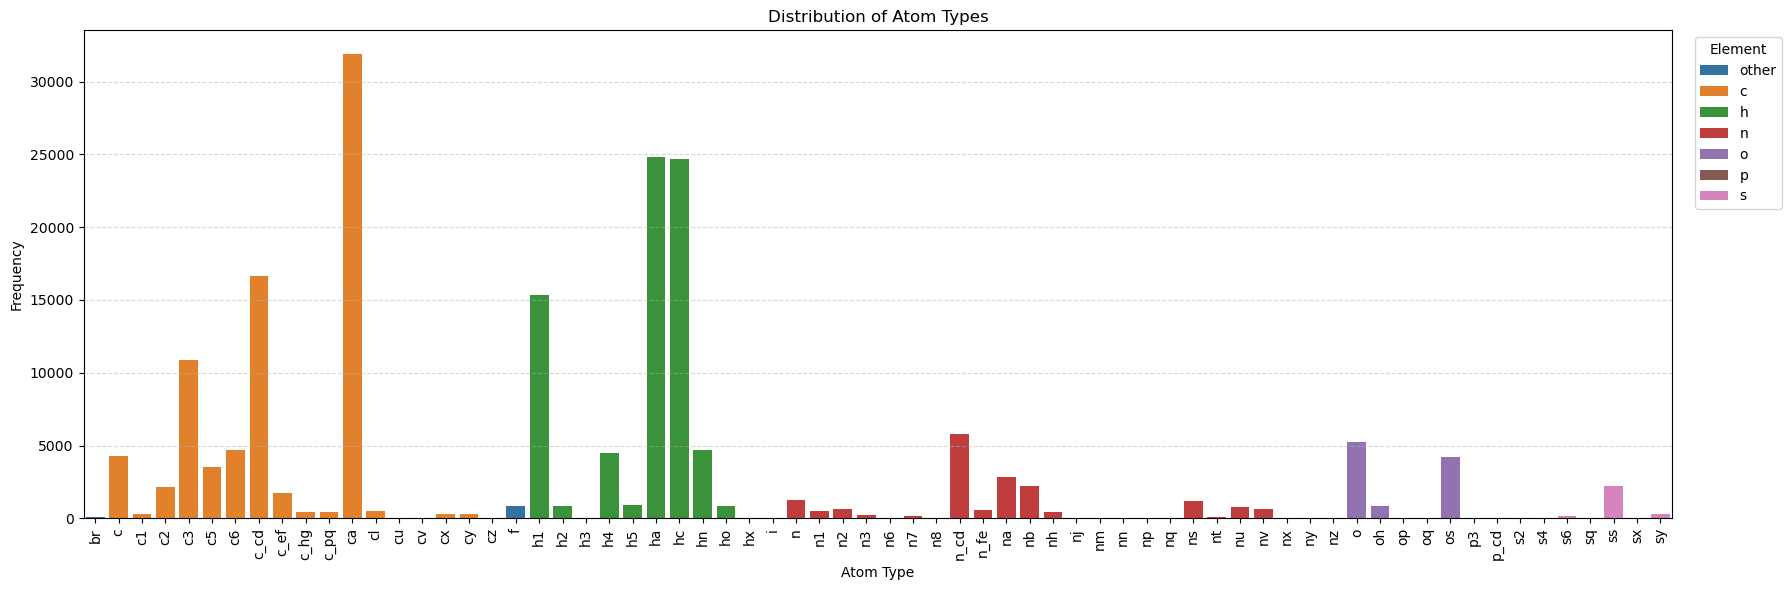

In [3]:
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution


# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(encoder.inverse_transform(dataset.encoded_labels)))



BaselineGCN - Number of parameters: 376900
--- Fold 1/5 ---


--- Fold 2/5 ---


--- Fold 3/5 ---


--- Fold 4/5 ---


--- Fold 5/5 ---


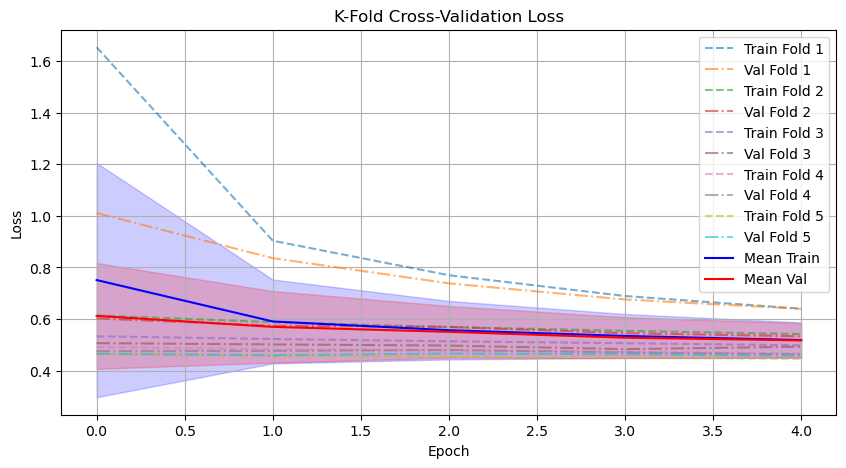

{'train_loss': [[1.6536215399565524,
   0.9035726307495839,
   0.7697917817324409,
   0.6891430928443302,
   0.640060638573889],
  [0.6139236397710388,
   0.5877652299148262,
   0.5687803415597371,
   0.5544273580251164,
   0.5415895479054532],
  [0.5331053417465624,
   0.5226288708386949,
   0.51376246813712,
   0.5061580532373411,
   0.498162826798954],
  [0.4913470939161175,
   0.4822562947371305,
   0.4781582962442935,
   0.4724312093511903,
   0.46671234718180904],
  [0.46322679433856667,
   0.4568960091240404,
   0.45324459783736787,
   0.4499187953094312,
   0.4457815056958626]],
 'val_loss': [[1.0109014778088639,
   0.8359749526387246,
   0.73825853888318,
   0.6757912754504247,
   0.6394445331462882],
  [0.6024221117067746,
   0.5741488590713986,
   0.5696564129417343,
   0.5450796436823427,
   0.5330918914547118],
  [0.5064899551072691,
   0.5015659180565951,
   0.49720850492045,
   0.4832877705861088,
   0.4926394346942447],
  [0.47548677082852353,
   0.47638939499109206,
  

In [4]:
from atoMLtype.models.GNN.BaselineGNNs import BaselineGCN

# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=train_dataset[0].x.shape[1],
                    encoder=encoder, 
                    hidden_dim=512)

trainer = GNNTrainer(model,
                     dataset=train_dataset, 
                     batch_size=32, 
                     learning_rate=0.001,
                      epochs=5, 
                      k_folds=5, 
                      random_seed=21)

trainer.train()

Prediction Summary: 15737/18717 correct (84.08% accuracy)
True label distribution: Counter({np.str_('ca'): 3219, np.str_('ha'): 2505, np.str_('hc'): 2370, np.str_('h1'): 1675, np.str_('c_cd'): 1672, np.str_('c3'): 1109, np.str_('n_cd'): 601, np.str_('o'): 512, np.str_('hn'): 471, np.str_('c6'): 453, np.str_('h4'): 448, np.str_('os'): 443, np.str_('c'): 416, np.str_('c5'): 357, np.str_('na'): 295, np.str_('ss'): 219, np.str_('c2'): 198, np.str_('c_ef'): 193, np.str_('nb'): 191, np.str_('ns'): 131, np.str_('n'): 115, np.str_('oh'): 87, np.str_('ho'): 87, np.str_('h5'): 87, np.str_('f'): 81, np.str_('nu'): 80, np.str_('h2'): 73, np.str_('n2'): 70, np.str_('nv'): 62, np.str_('n1'): 59, np.str_('cl'): 58, np.str_('nh'): 56, np.str_('n_fe'): 53, np.str_('c1'): 36, np.str_('c_hg'): 36, np.str_('cx'): 35, np.str_('sy'): 31, np.str_('c_pq'): 30, np.str_('cy'): 27, np.str_('n3'): 25, np.str_('s6'): 13, np.str_('nt'): 13, np.str_('n7'): 6, np.str_('n8'): 4, np.str_('br'): 3, np.str_('nn'): 2, np.

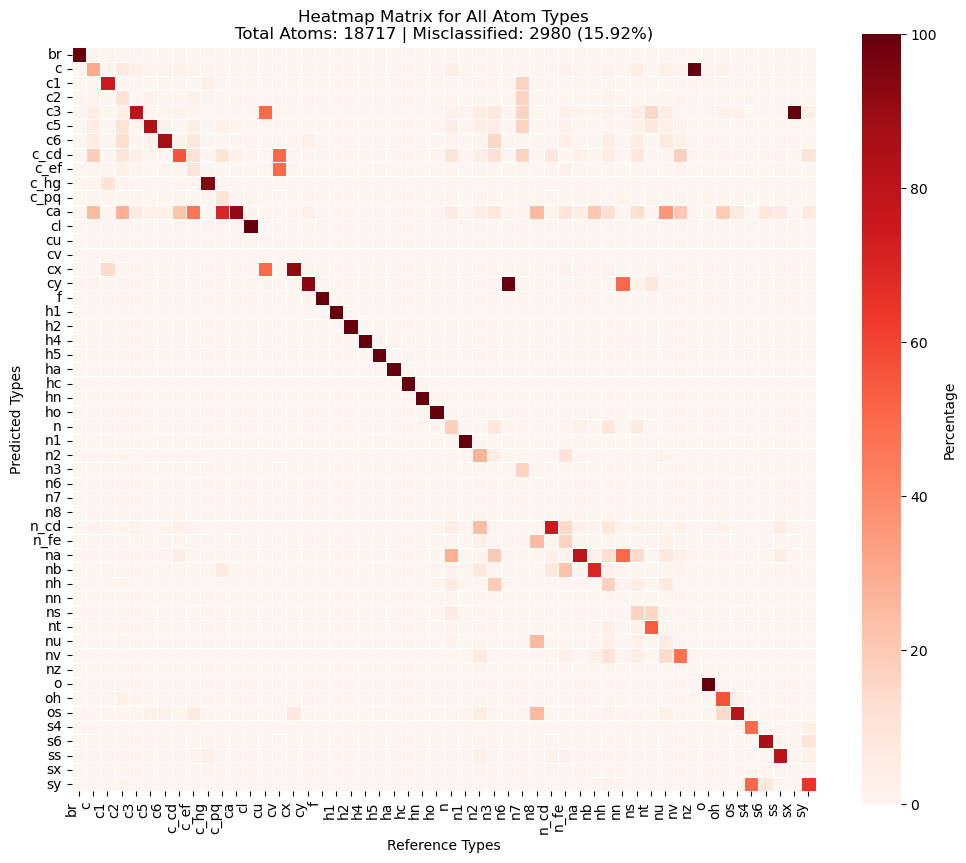

In [5]:
from atoMLtype.models.ModelEngine import ModelEngine
from atoMLtype.analysis.heatmaps import plot_full_heatmap

modelEngine = ModelEngine(model=model, 
                          dataset=test_dataset, 
                          device="cpu", 
                          batch_size=32)

predictionRecord = modelEngine.predict(analysis=False)

predictionRecord.summary()

plot_full_heatmap(predictionRecord)

# Test DMPNN with directed Edge GNNDataset

In [6]:
dirEdge_encoder = ModelEncoder(collapse=True)

# Initialize dataset
dirEdge_dataset = GNNdataset(sdf_path, 
                              json_labels, 
                              directed_graph=True, # Directed edges
                              labeled=True,
                              encoder=dirEdge_encoder)

[2025-04-30 15:28:38,523] INFO - Loaded atom type labels for 6410 molecules from data/antechamber/atomLabels_gaff2.json


[2025-04-30 15:28:38,608] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-30 15:28:38,673] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-30 15:28:38,864] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-30 15:28:39,002] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-30 15:28:39,147] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-30 15:28:39,266] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-30 15:28:39,310] WARNING - Atom count mismatch for ZINC06661321: 17 atoms in SDF, but 26 labels in JSON.
[2025-04-30 15:28:39,495] WARNING - Atom count mismatch for ZINC17108217: 25 atoms in SDF, but 29 labels in JSON.
[2025-04-30 15:28:39,567] WARNING - Atom count mismatch for ZINC41492619: 36 atoms in SD

FULL DATASET (encoded):


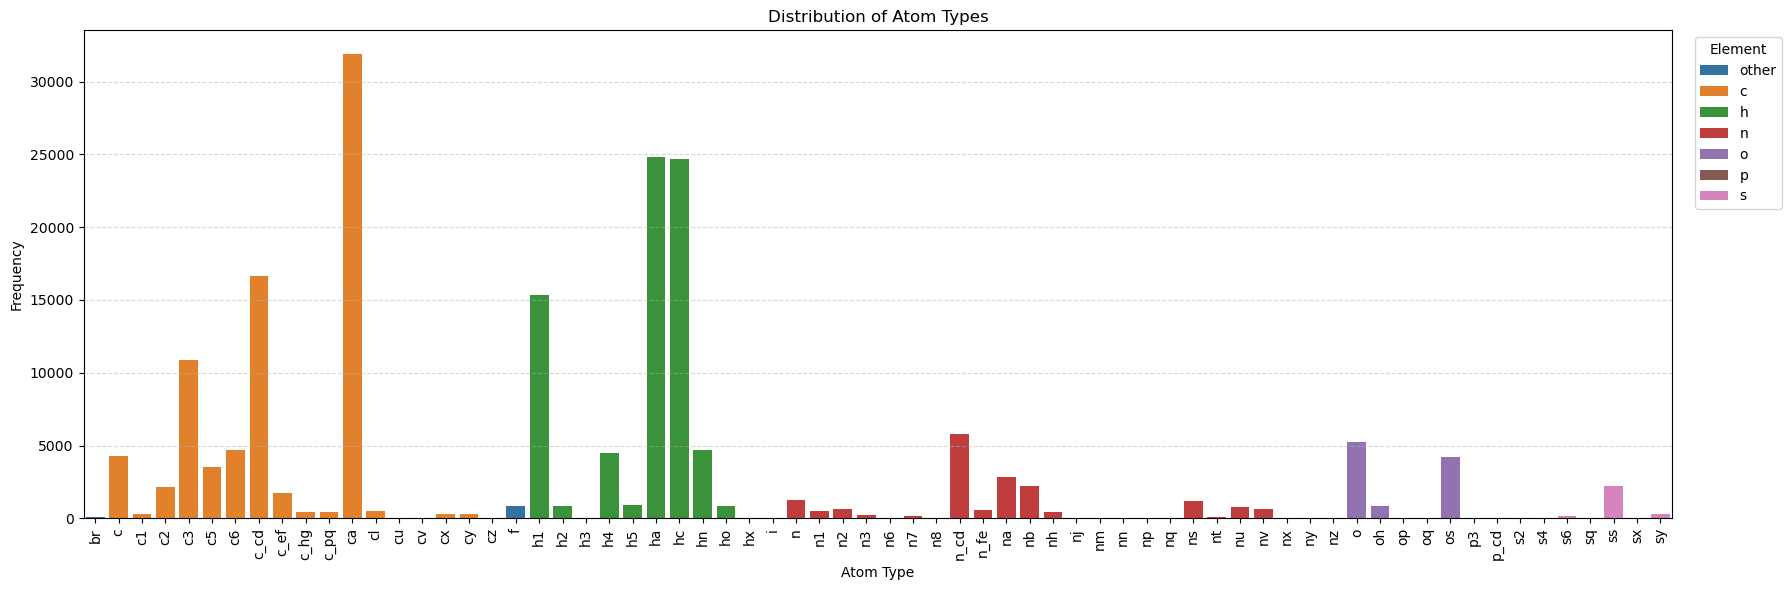

In [7]:
# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(dirEdge_dataset))
test_size = len(dirEdge_dataset) - train_size
train_dataset, test_dataset = random_split(dirEdge_dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(dirEdge_encoder.inverse_transform(dirEdge_dataset.encoded_labels)))

AtomBondMPNN - Number of parameters: 10985550
--- Fold 1/5 ---


Epoch 1: Train Loss = 2.4086, Val Loss = 0.1653
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.1563, Val Loss = 0.1222
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0498, Val Loss = 0.0491
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0424, Val Loss = 0.0351
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0249, Val Loss = 0.0446


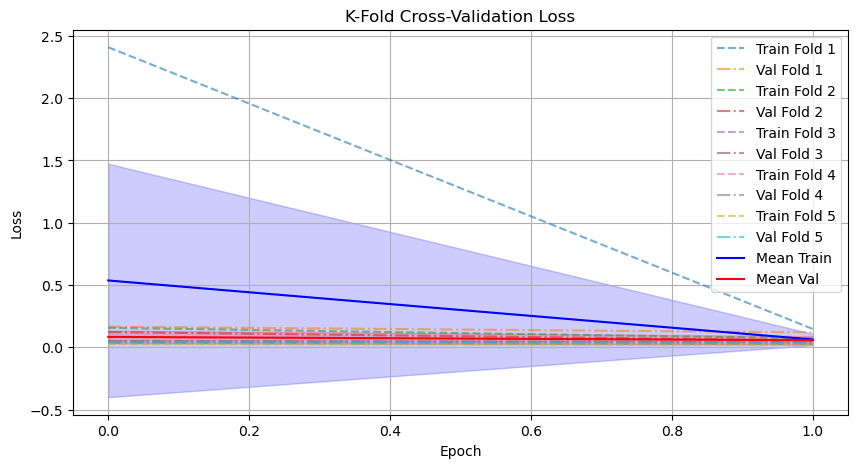

{'train_loss': [[2.4085703433960965, 0.14721697326937416],
  [0.15628437432080697, 0.07187161550301266],
  [0.04981280806661237, 0.040785939473859736],
  [0.04239926554154018, 0.03249084460217263],
  [0.024922969404951024, 0.01992598797157882]],
 'val_loss': [[0.1652932126807393, 0.11941359738639626],
  [0.12219323958644153, 0.05564010633048301],
  [0.04912470348214572, 0.0423961248195801],
  [0.0350904745870864, 0.0254556812178362],
  [0.04460035129903239, 0.041309148274646136]]}

In [8]:
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN

# With Attention
model_AtomMPNN_att = AtomBondMPNN(atom_input_dim=dirEdge_dataset[0].x.shape[1], 
                                      bond_input_dim=dirEdge_dataset[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=dirEdge_encoder, 
                                      num_layers=10,
                                      use_attention=True)

trainer_AtomMPNN_att  = GNNTrainer(model_AtomMPNN_att, 
                                   dataset=train_dataset, 
                                   batch_size=32, learning_rate=0.001,
                                   epochs=2, 
                                   k_folds=5, 
                                   random_seed=21)

trainer_AtomMPNN_att.train(verbose=True)

In [9]:
modelEngine_att = ModelEngine(model=model_AtomMPNN_att, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

MPNN_att_record = modelEngine_att.predict(analysis=True)

In [10]:
MPNN_att_record.summary()

Prediction Summary: 18460/18557 correct (99.48% accuracy)
True label distribution: Counter({np.str_('ca'): 3174, np.str_('hc'): 2535, np.str_('ha'): 2509, np.str_('c_cd'): 1628, np.str_('h1'): 1410, np.str_('c3'): 1043, np.str_('n_cd'): 551, np.str_('o'): 542, np.str_('h4'): 457, np.str_('c6'): 453, np.str_('c'): 446, np.str_('hn'): 443, np.str_('c5'): 394, np.str_('os'): 375, np.str_('na'): 295, np.str_('c2'): 245, np.str_('nb'): 221, np.str_('ss'): 206, np.str_('c_ef'): 199, np.str_('n'): 132, np.str_('ns'): 121, np.str_('h5'): 110, np.str_('f'): 84, np.str_('nu'): 82, np.str_('oh'): 82, np.str_('ho'): 82, np.str_('n_fe'): 68, np.str_('h2'): 63, np.str_('cl'): 62, np.str_('nv'): 60, np.str_('n1'): 60, np.str_('c_pq'): 60, np.str_('n2'): 54, np.str_('cx'): 45, np.str_('nh'): 42, np.str_('c_hg'): 42, np.str_('c1'): 39, np.str_('sy'): 34, np.str_('cy'): 29, np.str_('n3'): 21, np.str_('s6'): 12, np.str_('br'): 10, np.str_('nt'): 10, np.str_('n8'): 6, np.str_('nj'): 4, np.str_('n7'): 4, n

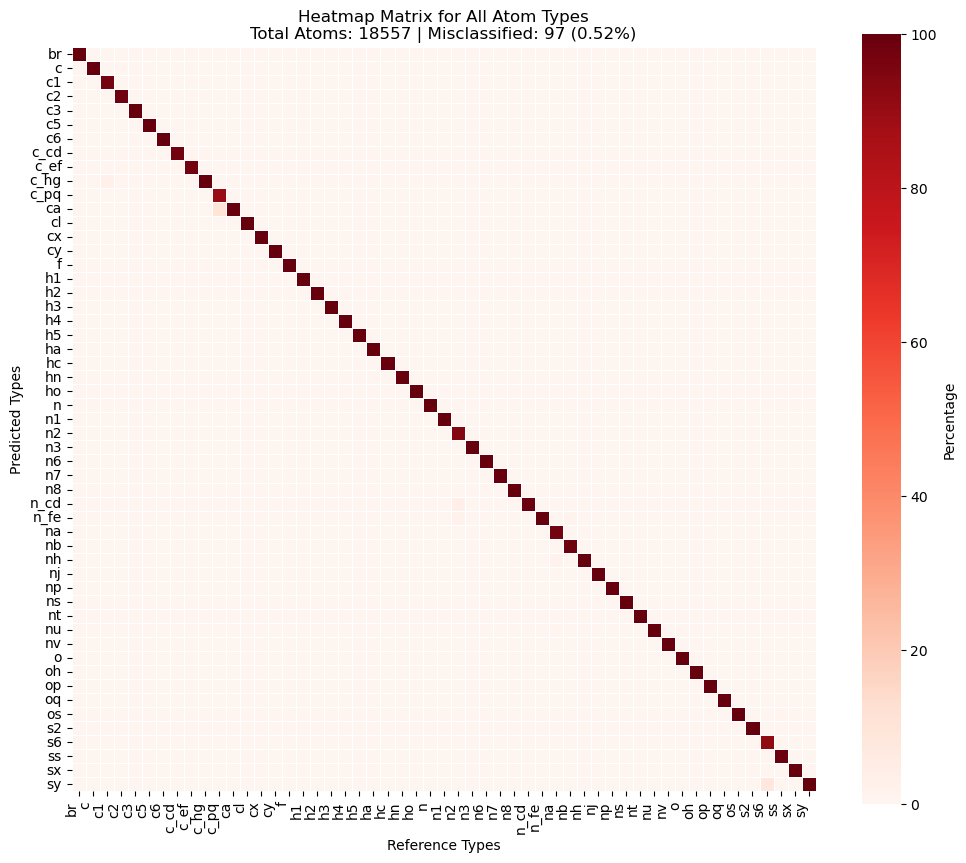

In [11]:
plot_full_heatmap(MPNN_att_record)

# Test Analysis refactoring

## Accuracy_counts

In [12]:
from atoMLtype.analysis.accuracy_counts import get_accuracies_and_counts

accuracie_counts = get_accuracies_and_counts(MPNN_att_record)

for item in accuracie_counts.items():
    print(item[0])
    print(item[1])

accuracy
0.994772861992779
atom_type_accuracy
{np.str_('c3'): 1.0, np.str_('c_cd'): 0.9778869778869779, np.str_('n_cd'): 0.9909255898366606, np.str_('ss'): 0.9902912621359223, np.str_('c_ef'): 0.9798994974874372, np.str_('ca'): 0.9924385633270322, np.str_('nb'): 0.9864253393665159, np.str_('hc'): 1.0, np.str_('h4'): 1.0, np.str_('ha'): 1.0, np.str_('os'): 1.0, np.str_('nu'): 1.0, np.str_('sy'): 1.0, np.str_('o'): 1.0, np.str_('n8'): 1.0, np.str_('hn'): 1.0, np.str_('br'): 1.0, np.str_('c2'): 0.9836734693877551, np.str_('n2'): 0.9444444444444444, np.str_('c5'): 1.0, np.str_('h1'): 1.0, np.str_('ns'): 1.0, np.str_('c'): 1.0, np.str_('oh'): 1.0, np.str_('ho'): 1.0, np.str_('c6'): 1.0, np.str_('h2'): 1.0, np.str_('na'): 0.9728813559322034, np.str_('nj'): 1.0, np.str_('cy'): 1.0, np.str_('nh'): 1.0, np.str_('n'): 1.0, np.str_('n_fe'): 1.0, np.str_('nv'): 1.0, np.str_('f'): 1.0, np.str_('cl'): 1.0, np.str_('h5'): 1.0, np.str_('c_hg'): 1.0, np.str_('n1'): 1.0, np.str_('c_pq'): 0.9, np.str_('c

## ConfusionMatrices

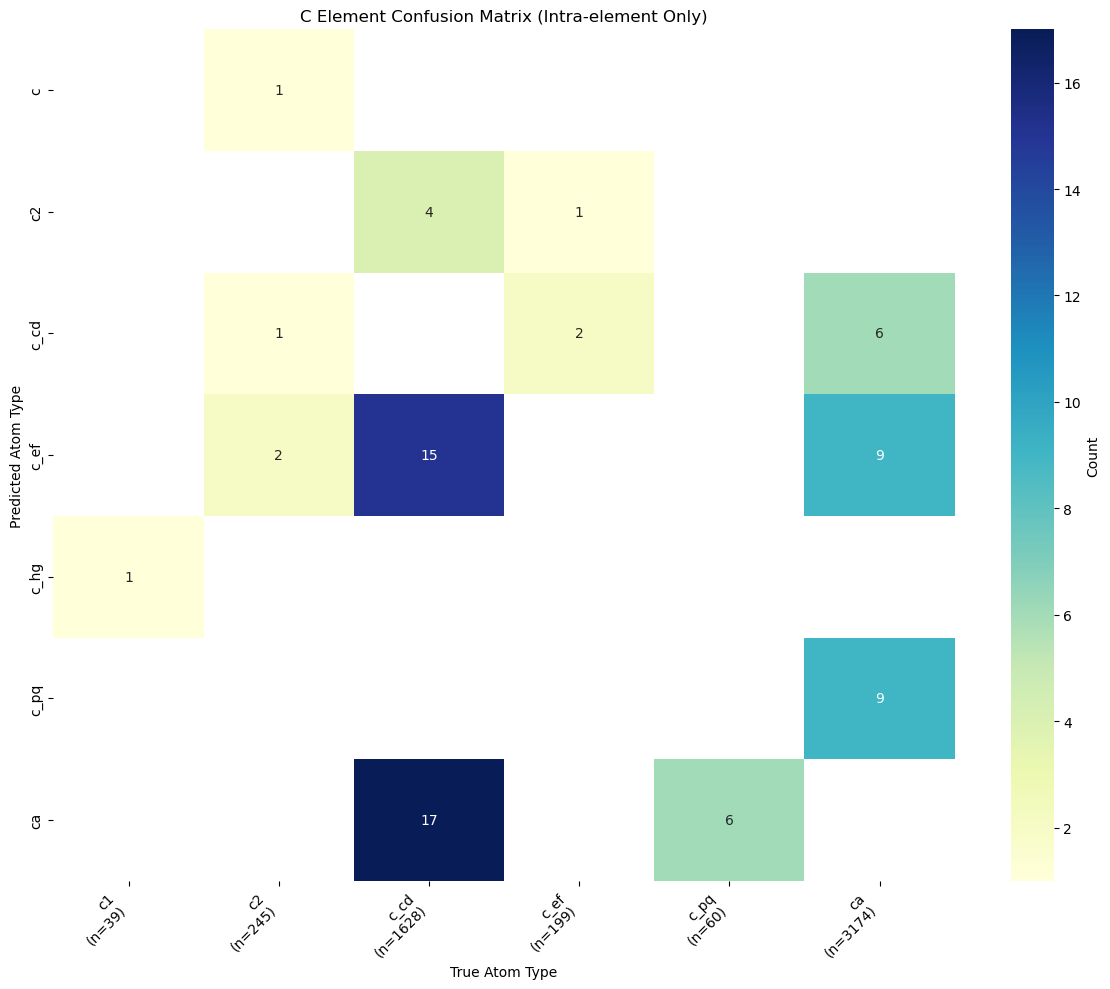

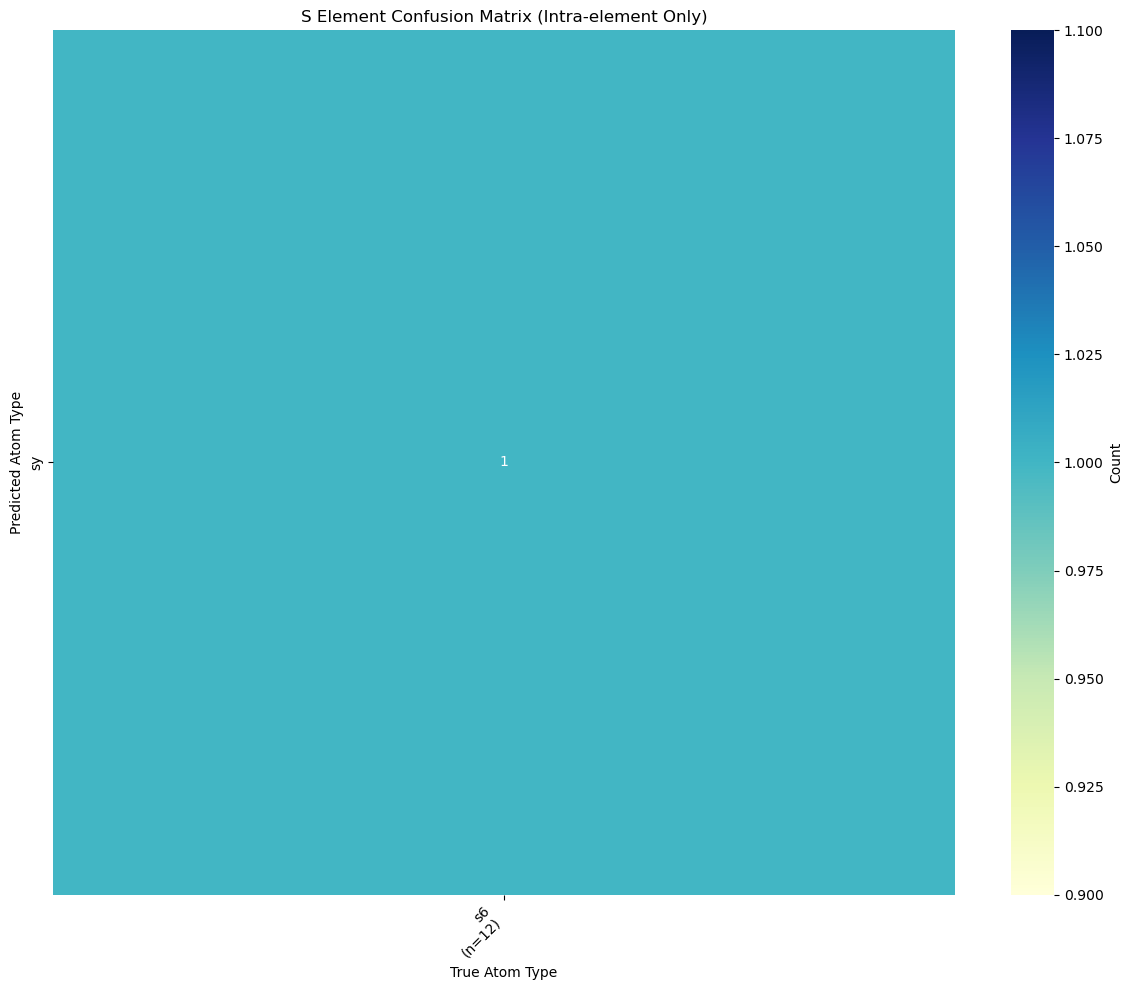

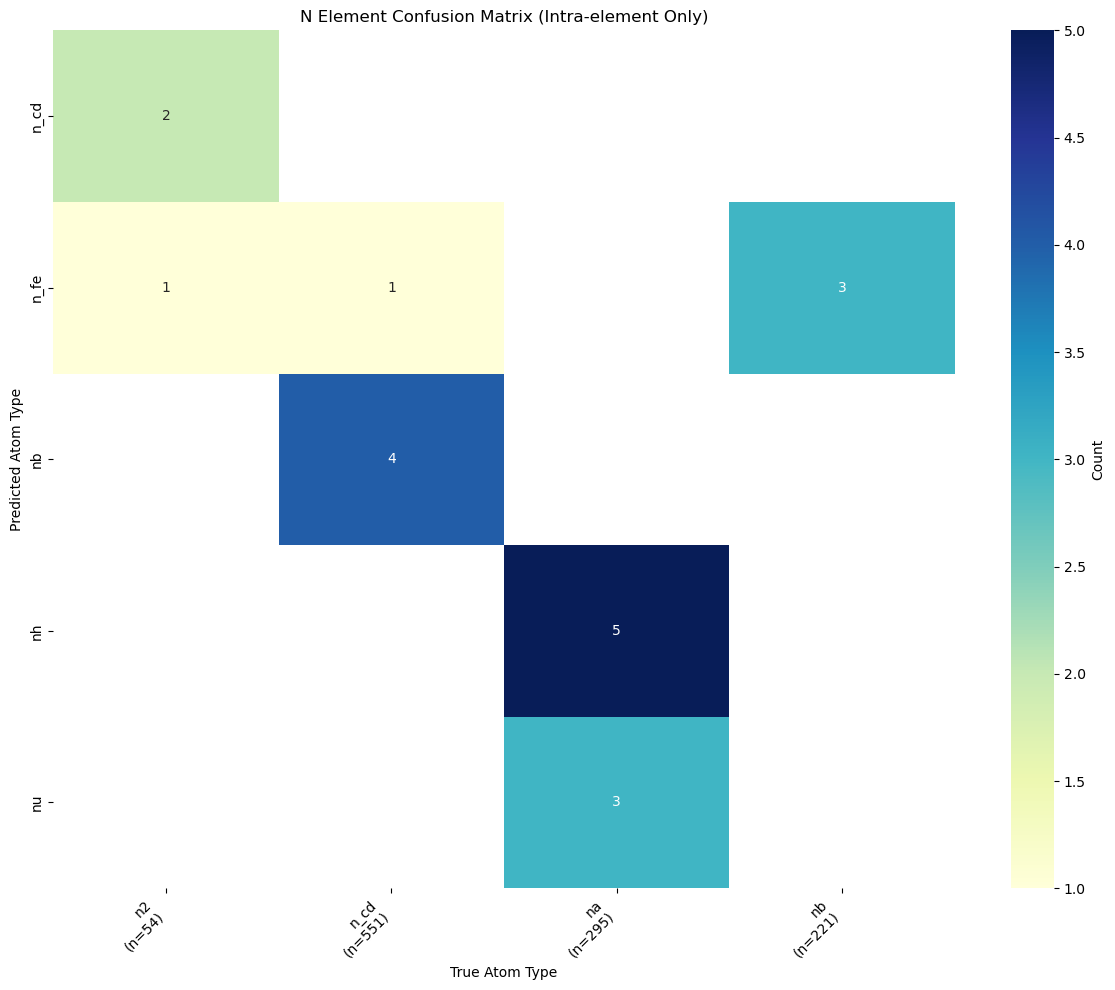

In [13]:
from atoMLtype.analysis.confusionMatrices import plot_full_confusion_matrices, plot_element_confusion_matrices

plot_element_confusion_matrices(MPNN_att_record)


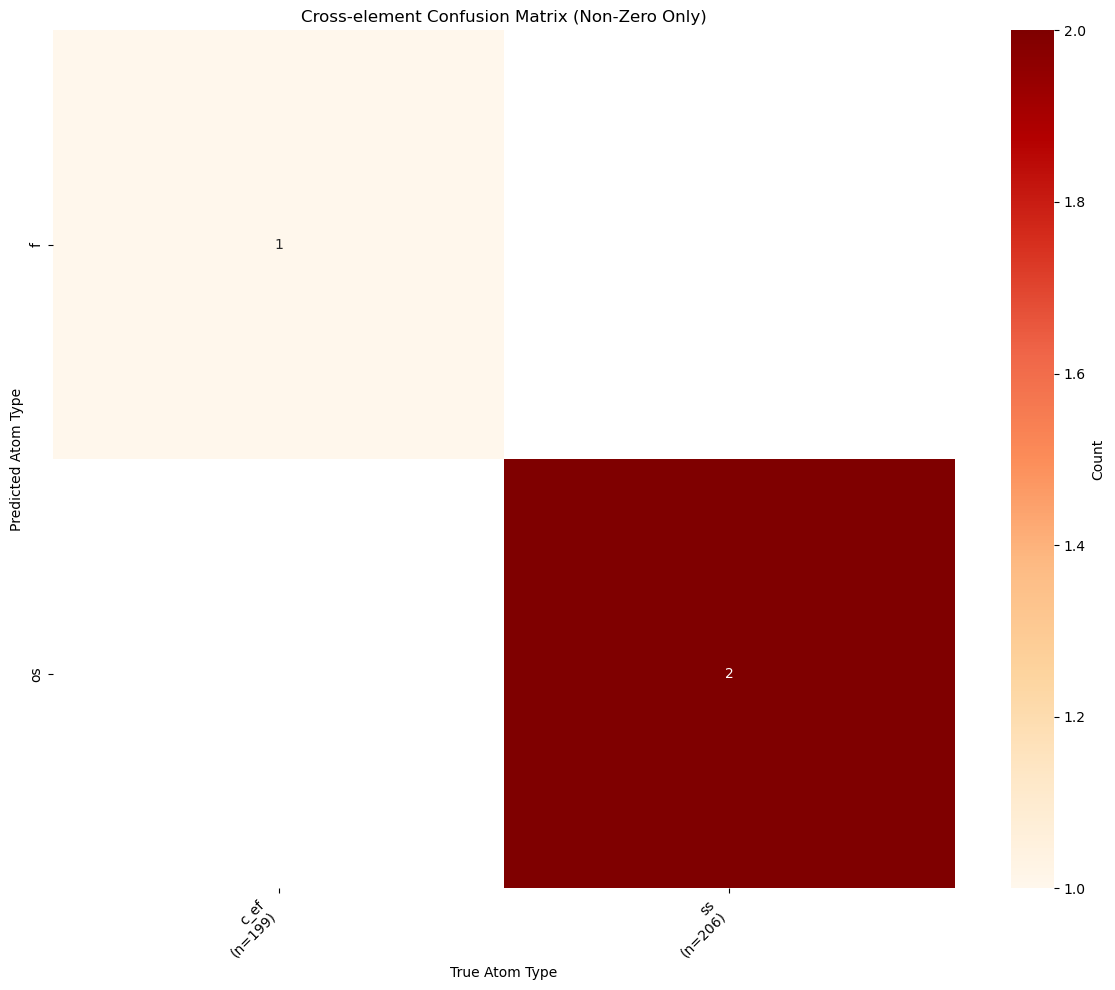

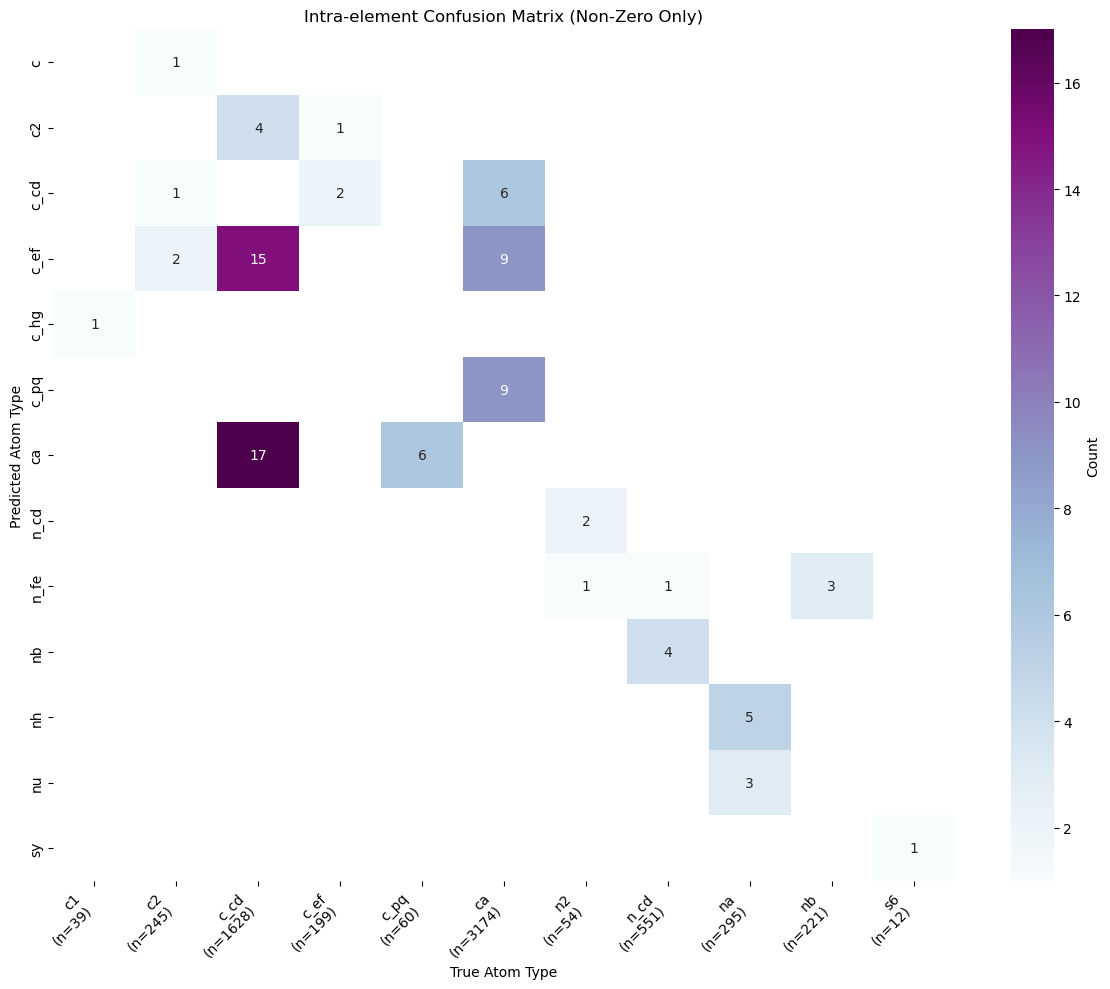

In [14]:
plot_full_confusion_matrices(MPNN_att_record)

## Discrepancies

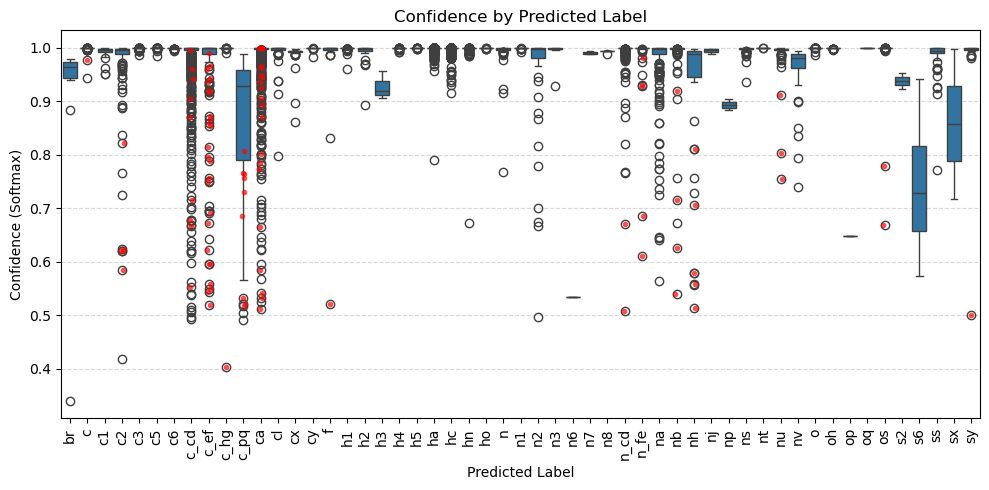

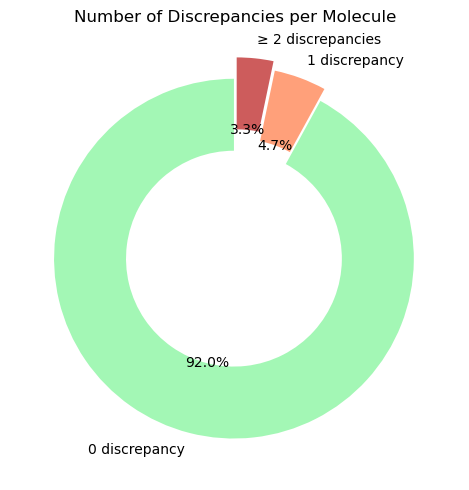

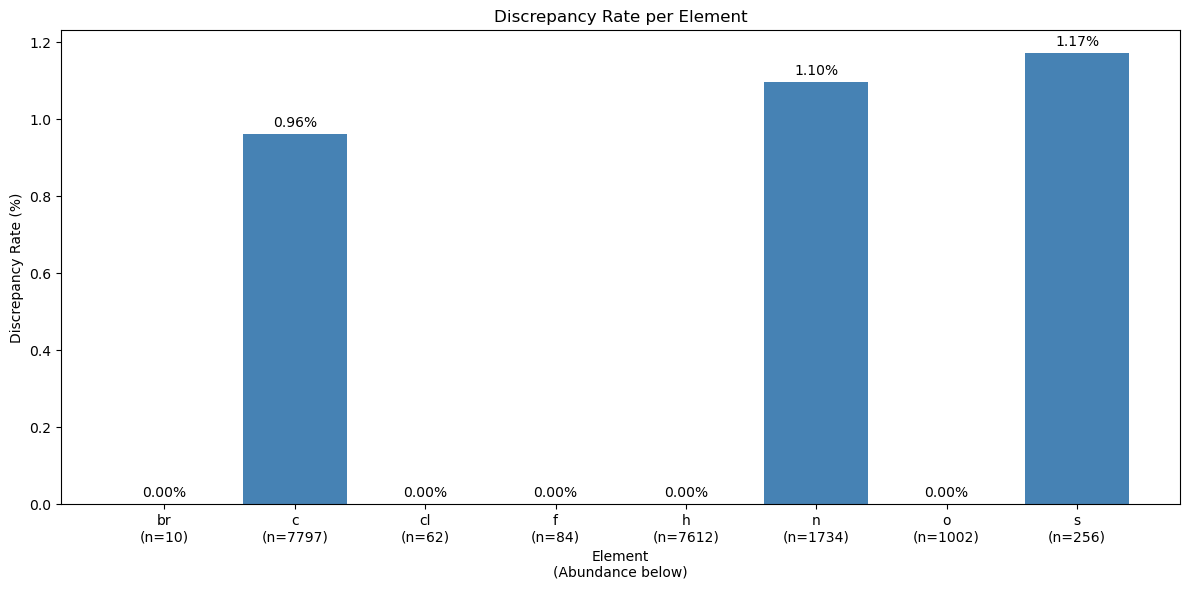

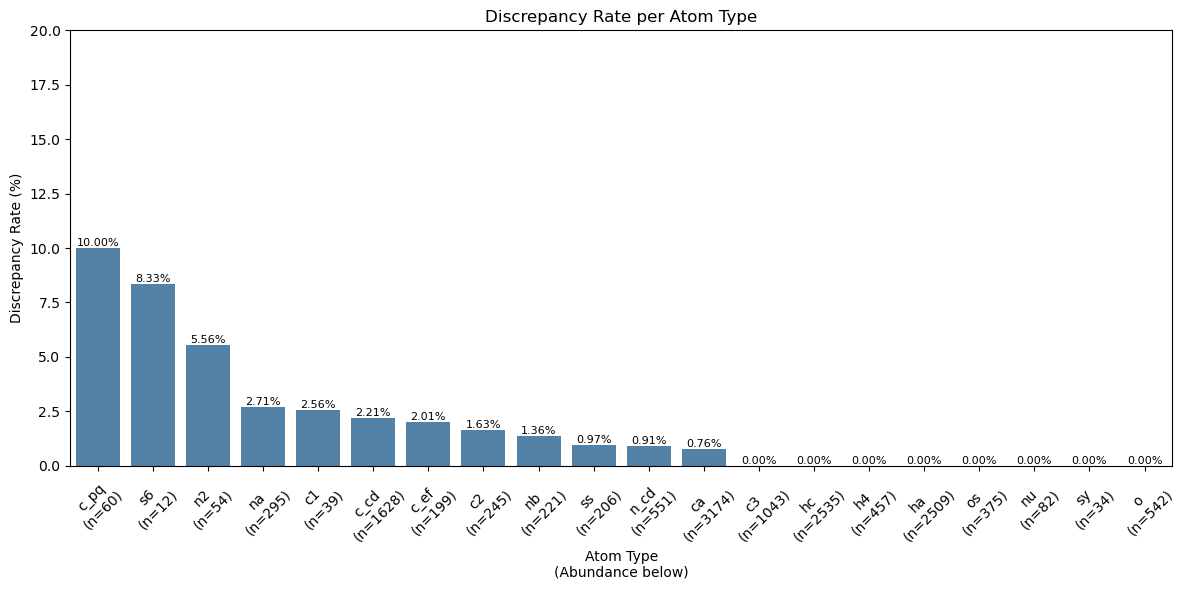

In [16]:
from atoMLtype.analysis.discrepancies import plot_confidence_by_pred_label, plot_discrepancy_distribution, plot_element_discrepancy_rate, plot_discrepancy_rate_by_atom_type

plot_confidence_by_pred_label(MPNN_att_record, 
                              sort_by='alphabetical',
                              show_mismatch=True,
                              showfliers=True, 
                              figsize=(10, 5))

plot_discrepancy_distribution(MPNN_att_record)


valid_elements = {
        "f", "cl", "br", "i", "c", "h", "n", "o", "s", "p"
    }

plot_element_discrepancy_rate(MPNN_att_record, valid_elements)

plot_discrepancy_rate_by_atom_type(MPNN_att_record)

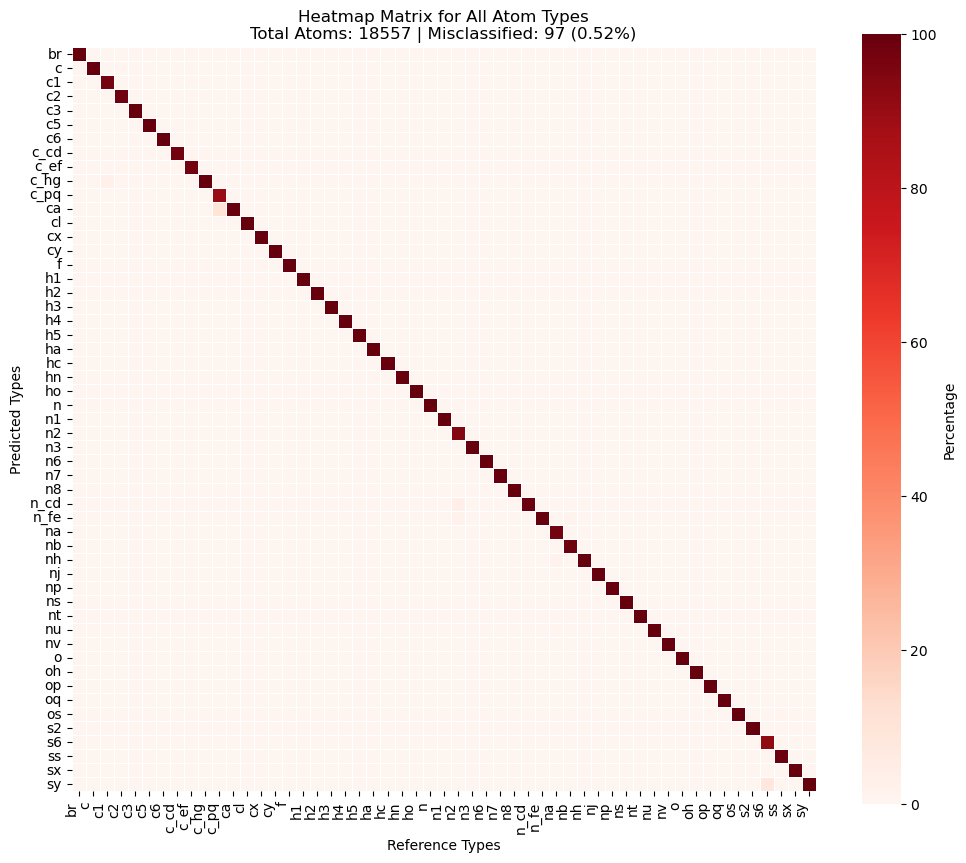

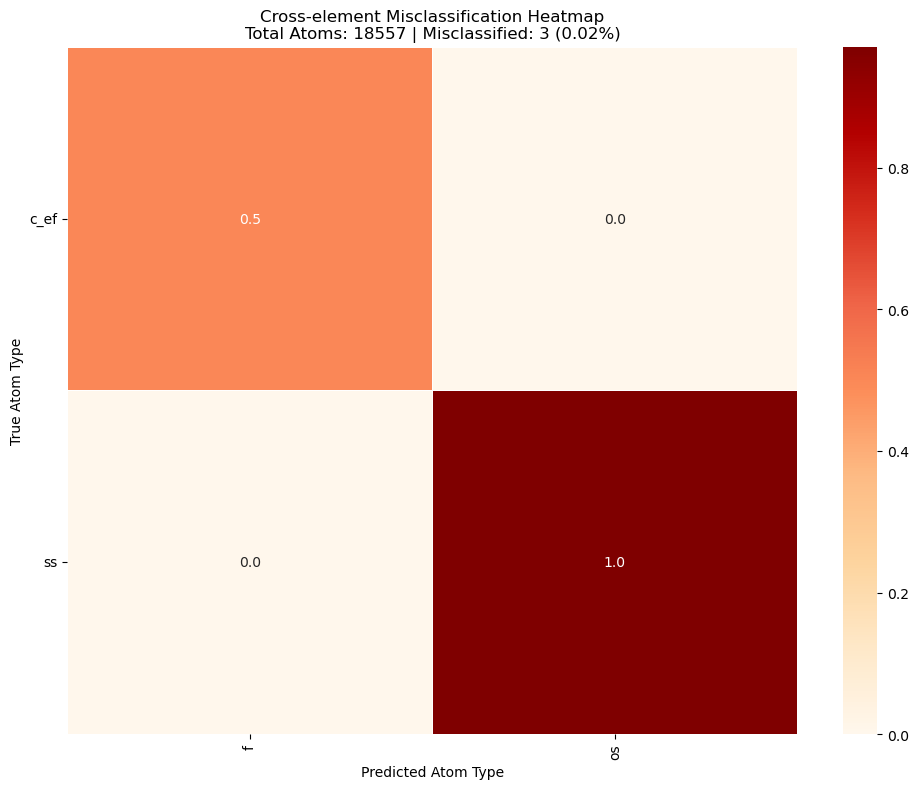

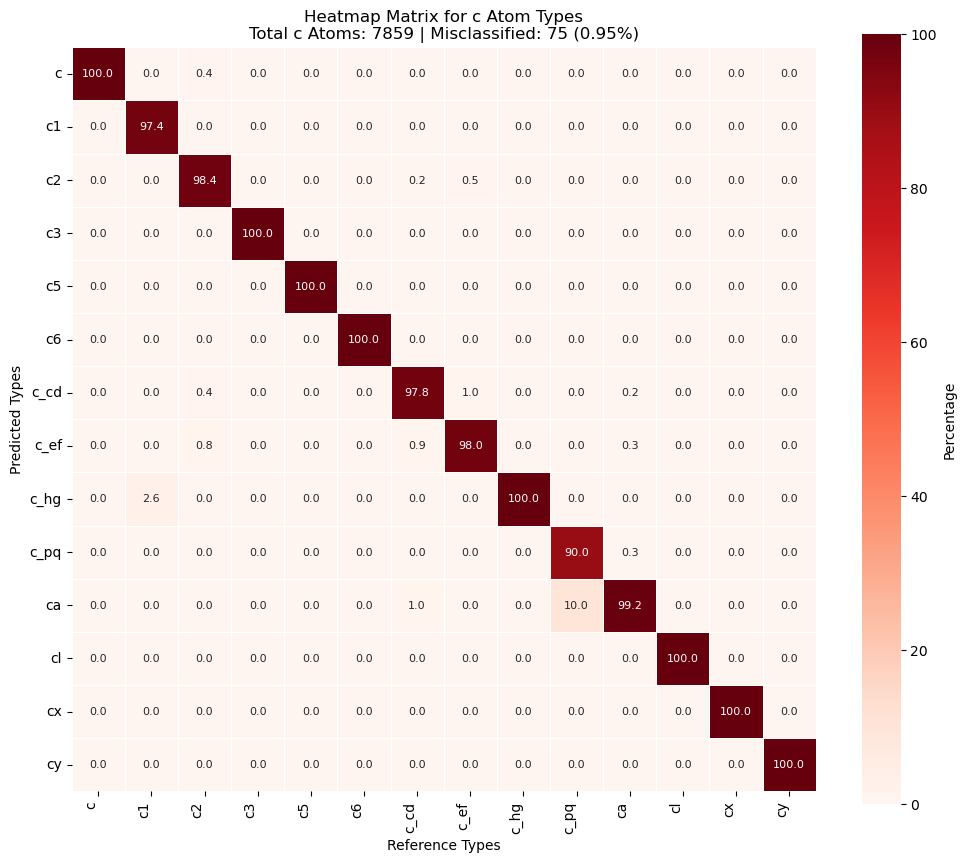

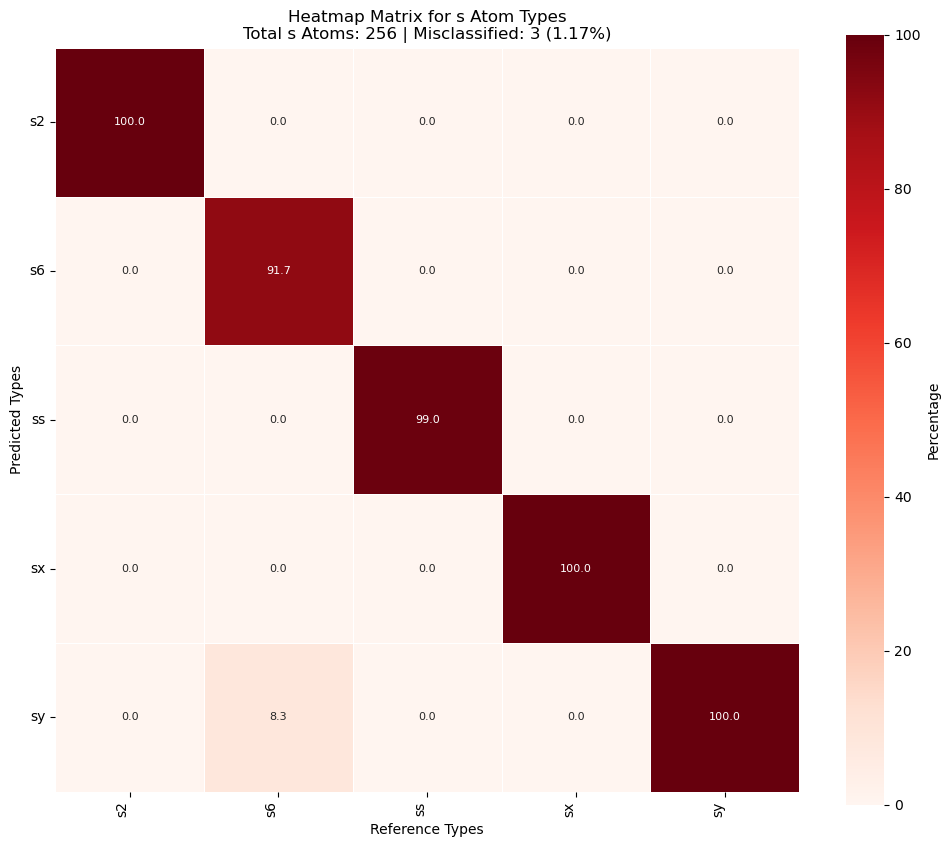

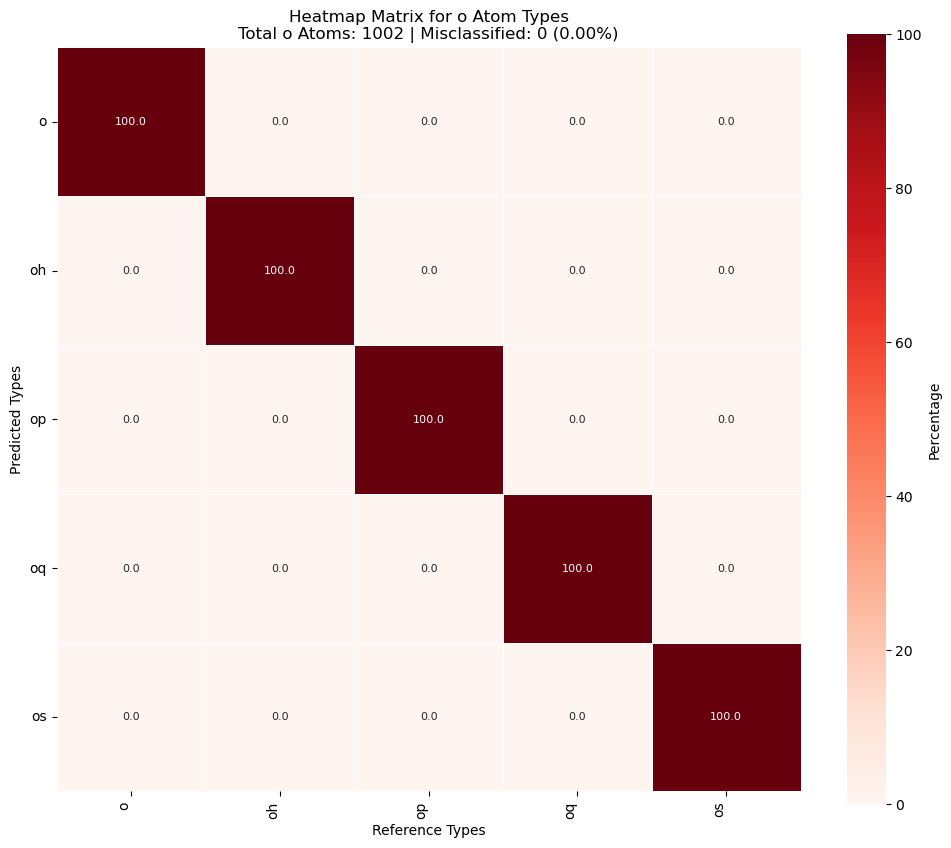

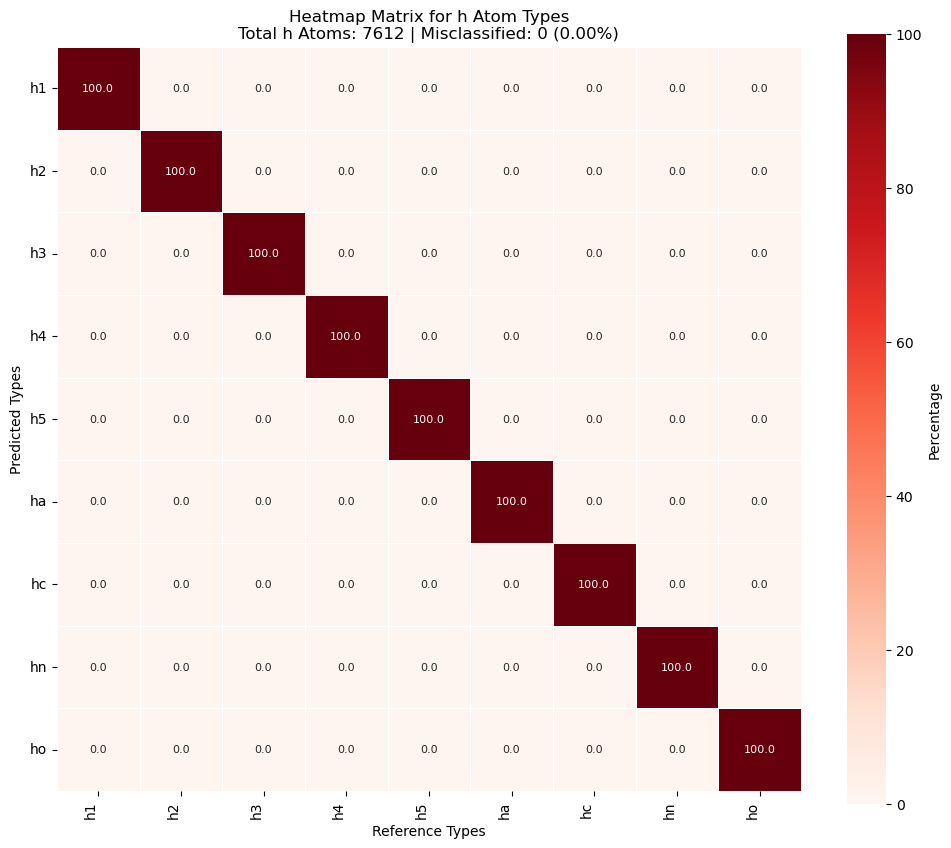

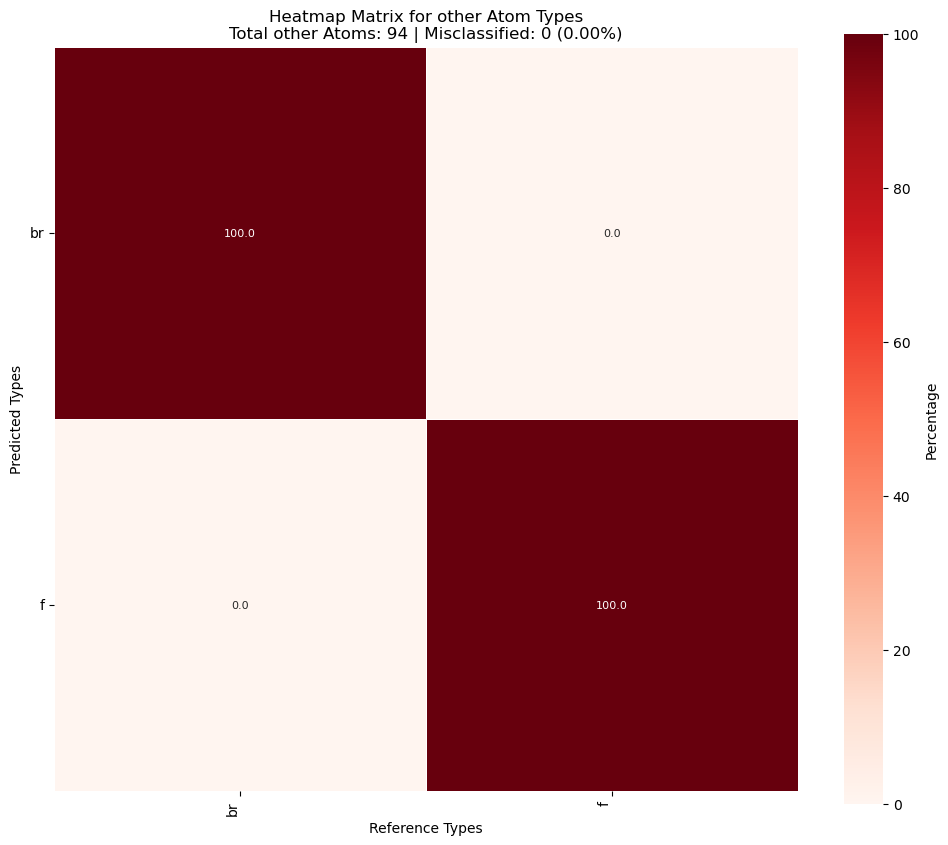

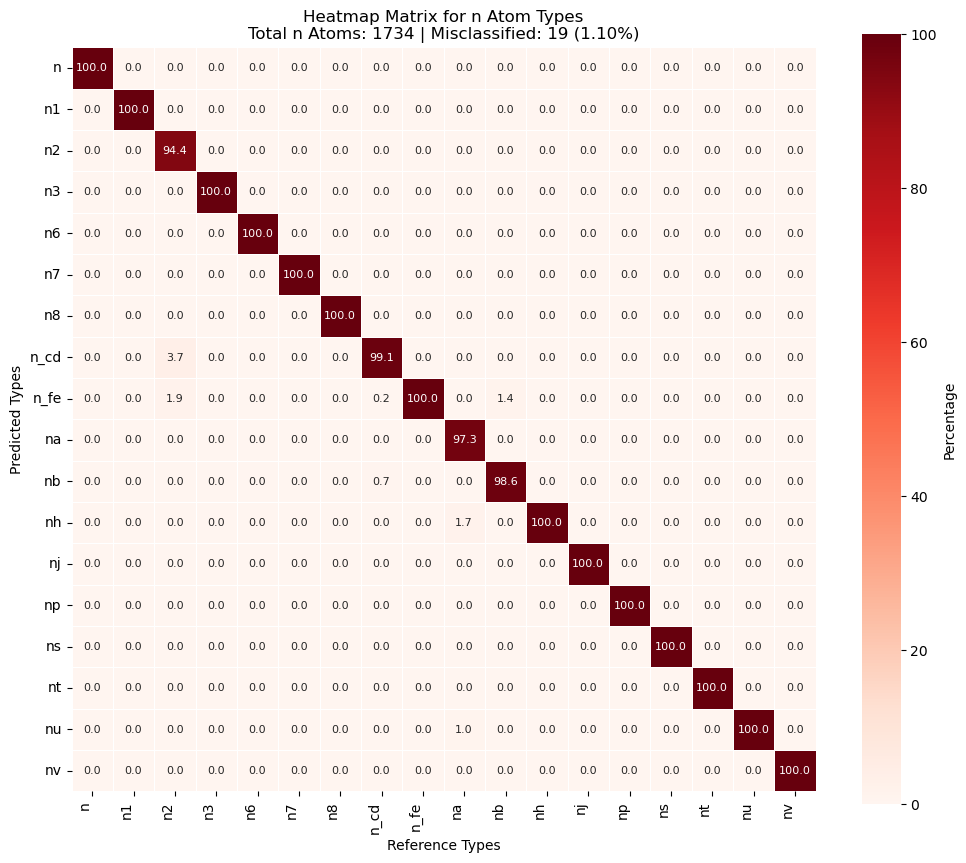

In [17]:
from atoMLtype.analysis.heatmaps import plot_full_heatmap, plot_cross_element_heatmap, plot_element_heatmap

plot_full_heatmap(MPNN_att_record)

plot_cross_element_heatmap(MPNN_att_record)

plot_element_heatmap(MPNN_att_record)

## Molecule_embeddings

/home/jeremymillford/biovia_week_13/Biovia-1/atoMLtype/analysis/molecule_embeddings.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


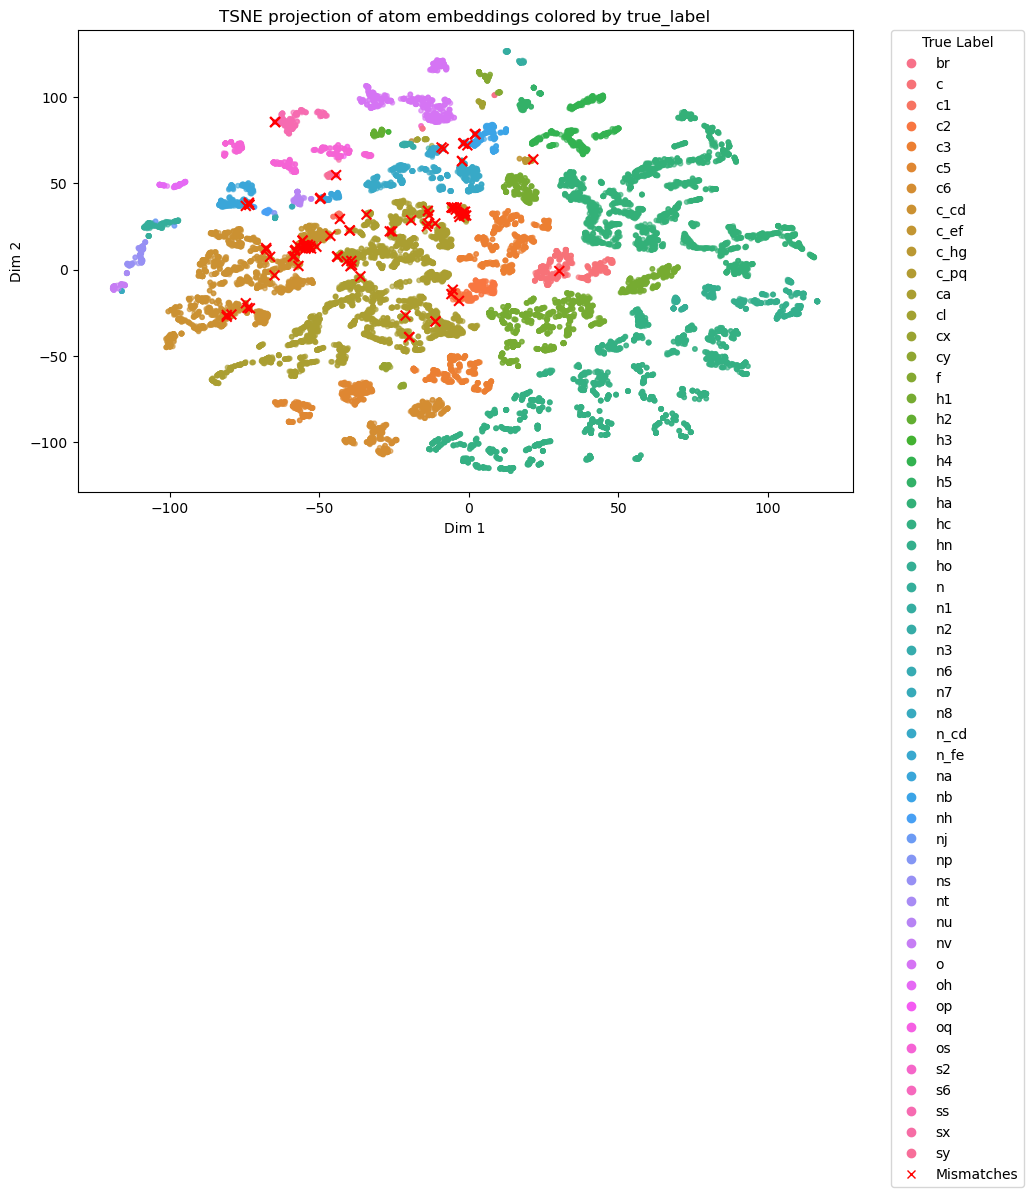

In [18]:

from atoMLtype.analysis.molecule_embeddings import visualize_prediction_embeddings

visualize_prediction_embeddings(
    pred_record=MPNN_att_record,
    key='clf_embeddings',
    method='tsne'
)

ZINC03120897 atom 1, pred AT nh for na


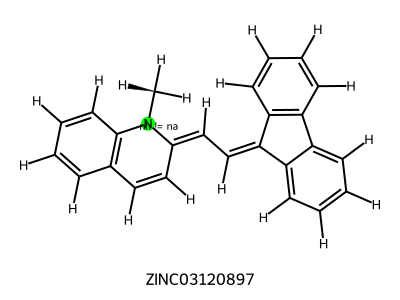

ZINC04667598 atom 3, pred AT ca for c_pq
ZINC04667598 atom 11, pred AT ca for c_pq


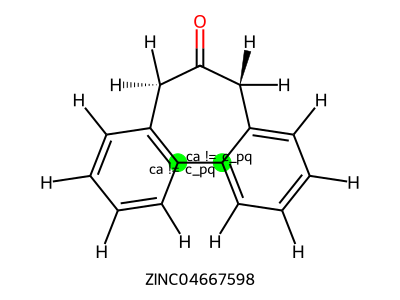

ZINC59422712 atom 10, pred AT os for ss


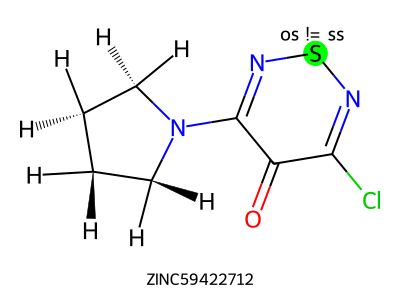

ZINC22013543 atom 7, pred AT n_cd for n2


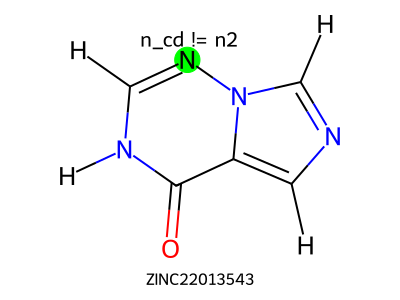

ZINC01609122 atom 7, pred AT c_ef for c_cd
ZINC01609122 atom 8, pred AT c_ef for c_cd
ZINC01609122 atom 9, pred AT c_ef for c_cd
ZINC01609122 atom 10, pred AT c_ef for c_cd
ZINC01609122 atom 11, pred AT c2 for c_cd


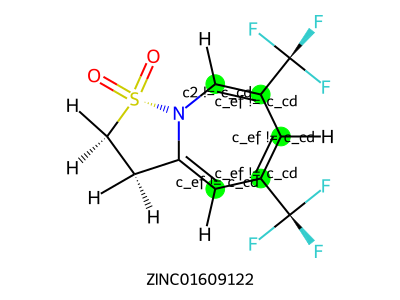

ZINC03861799 atom 6, pred AT f for c_ef
ZINC03861799 atom 7, pred AT ca for c_cd
ZINC03861799 atom 8, pred AT ca for c_cd
ZINC03861799 atom 9, pred AT ca for c_cd
ZINC03861799 atom 10, pred AT ca for c_cd
ZINC03861799 atom 12, pred AT ca for c_cd
ZINC03861799 atom 13, pred AT ca for c_cd


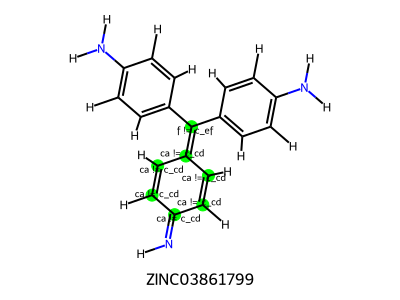

In [19]:
import atoMLtype.analysis.molecule_embeddings 
importlib.reload(atoMLtype.analysis.molecule_embeddings)
from atoMLtype.analysis.molecule_embeddings import draw_molecule_with_mismatches_labeled


mismatched_mols = MPNN_att_record.mismatched_molecules
original_dataset = getattr(test_dataset, 'dataset', test_dataset)

max = 5
count = 0

for mol_name, atom_preds in mismatched_mols.items():
    if count > max:
        break
    count += 1
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol = original_dataset.get_mol(mol_name)

    img = draw_molecule_with_mismatches_labeled(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")